In [1]:
# ===========================
# Standard Libraries
# ===========================
import os  # OS module for file and directory operations
import csv  # CSV module for reading and writing CSV files
import random  # Random module for generating random numbers
from os import listdir  # Function to list files in a directory
from os.path import isfile, join  # Functions to check file existence and join paths

# ===========================
# Third-Party Libraries
# ===========================
import cv2  # OpenCV library for image processing
from tqdm import tqdm  # Progress bar library for loops
import numpy as np  # NumPy library for numerical computations
import pandas as pd  # Pandas library for data manipulation
from matplotlib import pyplot as plt  # Matplotlib for plotting and visualization
from dataclasses import dataclass, field  # Python decorator for creating data classes

# ===========================
# PyTorch Libraries
# ===========================
import torch  # PyTorch library for deep learning
from torch.utils.data import (
    DataLoader,
    Dataset,
    random_split,
)  # Utilities for data handling
from torch.optim.lr_scheduler import ReduceLROnPlateau  # Learning rate scheduler
from torchinfo import summary  # Model summary utility

# ===========================
# Segmentation Models Library
# ===========================
import segmentation_models_pytorch as smp  # Pre-trained segmentation models

In [2]:
import warnings  # Import the warnings module to handle warning messages

# Suppress all warning messages to avoid cluttering the output
warnings.filterwarnings("ignore")


In [3]:
# ===========================
# Reproducibility Settings
# ===========================

# ---------------------------
# Seed Value
# ---------------------------
seed = 42  # Set a fixed seed value for reproducibility

# ---------------------------
# Python Random Module
# ---------------------------
# Set the seed for Python's built-in random module
random.seed(seed)

# ---------------------------
# NumPy Random Module
# ---------------------------
# Set the seed for NumPy to ensure reproducible random numbers
np.random.seed(seed)

# ---------------------------
# PyTorch Random Module
# ---------------------------
# Set the seed for PyTorch to ensure reproducibility in PyTorch operations
torch.manual_seed(seed)

# ---------------------------
# CUDA Random Module
# ---------------------------
# If CUDA is available, set the seed for CUDA operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)  # Set seed for the current GPU
    torch.cuda.manual_seed_all(
        seed
    )  # Set seed for all GPUs (if using multi-GPU setups)

# ---------------------------
# PyTorch Deterministic Behavior
# ---------------------------
torch.backends.cudnn.deterministic = True  # Use deterministic algorithms

# ---------------------------
# Disable Auto-Tuning
# ---------------------------
# Disabling auto-tuning for convolutional layers ensures deterministic behavior during training and evaluation.
# This is particularly important when reproducibility is required, as auto-tuning selects the fastest algorithm
# for the hardware, which can introduce non-deterministic results across runs.
torch.backends.cudnn.benchmark = False  # Disable auto-tuning for convolutional layers


#### **Variables and Path Declarations**

In [4]:
@dataclass
class params:
    """
    Configuration class to hold various parameters.
    """

    # ===========================
    # Paths
    # ===========================
    imageDirs: list = field(
        default_factory=lambda: [
            "G1020/Images_Square",
            "ORIGA/Images_Square",
            "REFUGE/Images_Square",
        ]
    )  # Paths to directories containing input images
    maskDirs: list = field(
        default_factory=lambda: [
            "G1020/Masks_Square",
            "ORIGA/Masks_Square",
            "REFUGE/Masks_Square",
        ]
    )  # Paths to directories containing corresponding masks

    # ===========================
    # Image Processing Parameters
    # ===========================
    HEIGHT: int = 256  # Target height for resizing images and masks
    WIDTH: int = 256  # Target width for resizing images and masks
    NUM_CLASSES: int = 3  # Number of classes in the segmentation task (e.g., background, class1, class2)
    NUM_CHANNELS: int = (
        3  # Number of channels in the input images (e.g., RGB images have 3 channels)
    )

    # ===========================
    # Data Augmentation Parameters
    # ===========================
    # Maximum rotation angle for image augmentation
    THETA = 15  # Maximum rotation angle (in degrees) for data augmentation

    # ===========================
    # Data Handling Flags
    # ===========================
    # Flag to determine whether to recreate the data or use pre-saved data
    RERUN: bool = False  # If True, regenerate data; if False, use pre-saved data

    # ===========================
    # Interpolation Methods
    # ===========================
    # Interpolation methods for resizing images and masks
    imgInterpolation: int = (
        cv2.INTER_LANCZOS4
    )  # High-quality interpolation for resizing images
    maskInterpolation: int = (
        cv2.INTER_NEAREST
    )  # Nearest-neighbor interpolation for resizing masks (preserves discrete labels)


In [5]:
@dataclass
class modelParams:
    """
    Configuration class to hold model parameters.
    """

    # ===========================
    # Training Parameters
    # ===========================
    BACKBONE: int = "efficientnet-b7" # Backbone model for the segmentation task
    epochs: int = 50  # Number of epochs for training the model
    lr: float = 0.001  # Learning rate for the optimizer
    patience: int = 3  # Number of epochs to wait before reducing the learning rate if no improvement
    mode: str = "min"  # Objective is to minimize the Loss during training

    # ===========================
    # Batch Parameters
    # ===========================
    BATCH_SIZE: int = 16  # Batch size for training and validation

    # ===========================
    # Learning Rate Scheduler
    # ===========================
    factor: float = 0.5  # Factor by which the learning rate will be reduced


In [6]:
imageDirs = ["G1020/Images_Square", "ORIGA/Images_Square", "REFUGE/Images_Square"]
maskDirs = ["G1020/Masks_Square", "ORIGA/Masks_Square", "REFUGE/Masks_Square"]


#### **Helper Functions**

In [7]:
def imgCLAHE(img: np.array) -> np.array:
    """
    Apply Contrast Limited Adaptive Histogram Equalization (CLAHE) to enhance the contrast of an image.

    Args:
        img (np.array): Input image in BGR color space.

    Returns:
        np.array: Contrast-enhanced image in BGR color space.
    """
    # ===========================
    # Convert to LAB Color Space
    # ===========================
    imgLAB = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    # ===========================
    # Apply CLAHE to L-Channel
    # ===========================
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    imgLAB[:, :, 0] = clahe.apply(imgLAB[:, :, 0])

    # ===========================
    # Convert Back to BGR
    # ===========================
    img = cv2.cvtColor(imgLAB, cv2.COLOR_LAB2BGR)

    # ===========================
    # Return Processed Image
    # ===========================
    return img.astype(np.uint8)


In [8]:
def getPath(imageDirs: list, maskDirs: list) -> tuple:
    """
    Function to retrieve and sort paths of image and mask files from given directories.

    Args:
        imageDirs (list): List of directories containing image files.
        maskDirs (list): List of directories containing mask files.

    Returns:
        tuple: Sorted lists of image paths and mask paths.
    """
    # ===========================
    # Initialize Path Lists
    # ===========================
    imagePath = []  # List to store image file paths
    maskPath = []  # List to store mask file paths

    # ===========================
    # Process Image Directories
    # ===========================
    for dir in imageDirs:
        if not os.path.exists(dir):  # Check if directory exists
            print(f"Warning: Directory {dir} does not exist.")
            continue
        # Collect paths of image files with .jpg extension
        imagePath.extend(
            [
                os.path.join(dir, f)
                for f in listdir(dir)
                if (f.endswith(".jpg") and isfile(join(dir, f)))
            ]
        )

    # ===========================
    # Process Mask Directories
    # ===========================
    for dir in maskDirs:
        if not os.path.exists(dir):  # Check if directory exists
            print(f"Warning: Directory {dir} does not exist.")
            continue
        # Collect paths of mask files with .png extension
        maskPath.extend(
            [
                os.path.join(dir, f)
                for f in listdir(dir)
                if (f.endswith(".png") and isfile(join(dir, f)))
            ]
        )

    # ===========================
    # Return Sorted Paths
    # ===========================
    return (sorted(imagePath), sorted(maskPath))


In [9]:
def imgRotate(img: np.array, mask: np.array) -> tuple:
    """
    Rotate an image and its corresponding mask by a random angle.

    Args:
        img (np.array): Input image.
        mask (np.array): Corresponding mask.

    Returns:
        tuple: Rotated image and mask.
    """
    # ===========================
    # Dimensions and Rotation Angle
    # ===========================
    h, w = mask.shape  # Get the height and width of the mask
    theta = random.randint(-params.THETA, params.THETA)  # Random rotation angle

    # ===========================
    # Rotation Matrix
    # ===========================
    rotation_point = (w // 2, h // 2)  # Define the center of rotation
    M = cv2.getRotationMatrix2D(
        rotation_point, angle=theta, scale=1.0
    )  # Compute matrix

    # ===========================
    # Apply Rotation
    # ===========================
    rotated_image = cv2.warpAffine(img, M, (w, h))  # Rotate the image
    rotated_mask = cv2.warpAffine(mask, M, (w, h))  # Rotate the mask

    # ===========================
    # Return Rotated Outputs
    # ===========================
    return (rotated_image, rotated_mask)


In [10]:
def imgFlip(img: np.array, mask: np.array) -> tuple:
    """
    Randomly flip an image and its corresponding mask horizontally, vertically, or both.

    Args:
        img (np.array): Input image in BGR format.
        mask (np.array): Corresponding mask in grayscale format.

    Returns:
        tuple: Flipped image and mask as a tuple.
    """
    # ===========================
    # Random Flip Type Selection
    # ===========================
    # Randomly select a flip type: 1 (horizontal), 0 (vertical), -1 (both horizontal and vertical), or None (no flip)
    flipType = random.choice([1, 0, -1, None])

    # ===========================
    # Apply Flip
    # ===========================
    # Apply the flip to both the image and the mask if flipType is not None
    if flipType is not None:
        img = cv2.flip(img, flipType)
        mask = cv2.flip(mask, flipType)

    # ===========================
    # Return Flipped Outputs
    # ===========================
    return (img, mask)


In [11]:
def imgResize(img: np.array, mask: np.array) -> tuple[np.array, np.array]:
    """
    Resize an image and its corresponding mask to the specified dimensions.

    Args:
        img (np.array): Input image.
        mask (np.array): Corresponding mask.

    Returns:
        tuple[np.array, np.array]: Resized image and mask.
    """
    # ===========================
    # Resize Image
    # ===========================
    img = cv2.resize(
        img, (params.WIDTH, params.HEIGHT), interpolation=params.imgInterpolation
    )

    # ===========================
    # Resize Mask
    # ===========================
    mask = cv2.resize(
        mask, (params.WIDTH, params.HEIGHT), interpolation=params.maskInterpolation
    )

    # ===========================
    # Return Resized Outputs
    # ===========================
    return (img, mask)


In [12]:
# ===========================
# Bilateral Filtering
# ===========================


def biLateralFilter(img: np.array) -> np.array:
    """
    Apply bilateral filtering to an image to reduce noise while preserving edges.

    Args:
        img (np.array): Input image in BGR format.

    Returns:
        np.array: Image after applying bilateral filter in BGR format.
    """
    # ===========================
    # Apply Bilateral Filter
    # ===========================
    img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    # ===========================
    # Return Filtered Image
    # ===========================
    return img.astype(np.uint8)


In [13]:
def imgTransformPipeline(img: np.array, mask: np.array) -> tuple:
    """
    Apply a series of transformations to an image and its corresponding mask.

    Args:
        img (np.array): Input image.
        mask (np.array): Corresponding mask.

    Returns:
        tuple: Transformed image and mask.
    """
    # ===========================
    # Resize
    # ===========================
    # Resize the image and mask to the specified dimensions
    img, mask = imgResize(img, mask)

    # ===========================
    # Flip
    # ===========================
    # Randomly flip the image and mask
    img, mask = imgFlip(img, mask)

    # ===========================
    # Rotate
    # ===========================
    # Rotate the image and mask by a random angle
    img, mask = imgRotate(img, mask)

    # ===========================
    # Normalize
    # ===========================
    # Normalize the image to the range (0.0, 1.0) using contrast stretching
    img = (img - img.min()) / (img.max() - img.min())

    # Ensure the image is properly normalized
    assert (img.min(), img.max()) == (0.0, 1.0), "Image NOT normalized"

    # ===========================
    # Return Transformed Outputs
    # ===========================
    # Return the transformed image and mask
    return (img, mask)


In [14]:
def visualize_prediction(
    image: np.array, gt_mask: np.array, pred_mask: np.array
) -> None:
    """
    Visualize the original image, ground truth mask, and predicted mask side by side.

    Args:
        image (np.array): The original input image.
        gt_mask (np.array): The ground truth mask.
        pred_mask (np.array): The predicted mask.
    """
    # ===========================
    # Prepare Image for Display
    # ===========================
    # Ensure the image is scaled back to 8-bit format for display
    image = (image * 255).astype(np.uint8)

    # ===========================
    # Create Subplots
    # ===========================
    # Create a figure with four subplots to display the images
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    # ===========================
    # Display Original Image
    # ===========================
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")  # Turn off axis labels for better visualization

    # ===========================
    # Display Ground Truth Mask
    # ===========================
    axes[1].imshow(gt_mask)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")  # Turn off axis labels for better visualization

    # ===========================
    # Display Predicted Mask
    # ===========================
    axes[2].imshow(pred_mask)
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")  # Turn off axis labels for better visualization

    # ===========================
    # Display Overlay
    # ===========================
    axes[3].imshow(image)
    axes[3].imshow(pred_mask, alpha=0.25)
    axes[3].set_title("Overlay")
    axes[3].axis("off")  # Turn off axis labels for better visualization

    # ===========================
    # Adjust Layout and Show
    # ===========================
    # Adjust the layout to prevent overlap between subplots
    fig.tight_layout()

    # Show the figure
    plt.show()


In [15]:
def one_hot_encode_masks(masks: np.array, num_classes: int) -> np.array:
    """
    One-hot encode the masks.

    Args:
        masks (np.array): Input masks with integer class indices.
        num_classes (int): Number of classes.

    Returns:
        np.array: One-hot encoded masks with shape (N, num_classes, H, W).
    """
    # ---------------------------
    # Ensure Integer Masks
    # ---------------------------
    masks = masks.astype(np.int8)

    # ---------------------------
    # Validate Mask Values
    # ---------------------------
    if masks.min() < 0 or masks.max() >= num_classes:
        raise ValueError(
            f"Mask values should be in the range [0, {num_classes - 1}]. "
            f"Found values in range [{masks.min()}, {masks.max()}]."
        )

    # ---------------------------
    # Perform One-Hot Encoding
    # ---------------------------
    one_hot_encoded_masks = np.eye(num_classes, dtype=np.float32)[masks.reshape(-1)]

    # ---------------------------
    # Reshape and Transpose
    # ---------------------------
    one_hot_encoded_masks = one_hot_encoded_masks.reshape(*masks.shape, num_classes)
    return one_hot_encoded_masks.transpose(0, 3, 1, 2)


In [16]:
def visualize_saved_parameters(csv_file: str) -> None:
    """
    Visualize the saved parameters from the CSV file in side-by-side graphs.

    Args:
        csv_file (str): Path to the CSV file containing the parameters.
    """
    # ===========================
    # Load CSV File
    # ===========================
    df = pd.read_csv(csv_file)

    # Extract the title from the filename
    title = os.path.basename(csv_file).split(".")[0].split("_")[0].upper()

    # ===========================
    # Create Subplots
    # ===========================
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))  # Adjusted layout for 7 plots
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    # ===========================
    # Plot Training and Validation Losses
    # ===========================
    axes[0].plot(df["Epoch"], df["Training Loss"], label="Training Loss")
    axes[0].plot(df["Epoch"], df["Validation Loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Losses")
    axes[0].legend()
    axes[0].grid()

    # ===========================
    # Plot IoU Scores
    # ===========================
    axes[1].plot(df["Epoch"], df["IoU Score"], label="IoU Score", color="blue")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_title("IoU Scores")
    axes[1].legend()
    axes[1].grid()

    # ===========================
    # Plot Dice Scores
    # ===========================
    axes[2].plot(df["Epoch"], df["Dice Score"], label="Dice Score", color="red")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Dice Scores")
    axes[2].legend()
    axes[2].grid()

    # ===========================
    # Plot Precision
    # ===========================
    axes[3].plot(df["Epoch"], df["Precision"], label="Precision", color="green")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Score")
    axes[3].set_title("Precision")
    axes[3].legend()
    axes[3].grid()

    # ===========================
    # Plot Recall
    # ===========================
    axes[4].plot(df["Epoch"], df["Recall"], label="Recall", color="orange")
    axes[4].set_xlabel("Epoch")
    axes[4].set_ylabel("Score")
    axes[4].set_title("Recall")
    axes[4].legend()
    axes[4].grid()

    # ===========================
    # Plot Specificity
    # ===========================
    axes[5].plot(df["Epoch"], df["Specificity"], label="Specificity", color="purple")
    axes[5].set_xlabel("Epoch")
    axes[5].set_ylabel("Score")
    axes[5].set_title("Specificity")
    axes[5].legend()
    axes[5].grid()

    # ===========================
    # Plot Accuracy
    # ===========================
    axes[6].plot(df["Epoch"], df["Accuracy"], label="Accuracy", color="pink")
    axes[6].set_xlabel("Epoch")
    axes[6].set_ylabel("Score")
    axes[6].set_title("Accuracy")
    axes[6].legend()
    axes[6].grid()

    # ===========================
    # Hide Unused Subplots
    # ===========================
    axes[7].axis("off")
    axes[8].axis("off")

    # =========================================
    # Add Main Title, Adjust Layout and Show
    # =========================================
    fig.suptitle(f"Performance Metrics {title} - UNET_Plus_Plus", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the main title
    plt.show()


In [17]:
# ===========================
# Dataset Class Definition
# ===========================


class SegmentationDataset(Dataset):
    """
    Custom PyTorch Dataset for segmentation tasks.
    """

    # ---------------------------
    # Initialization
    # ---------------------------
    def __init__(self, images, masks):
        """
        Initialize the dataset with images and masks.

        Args:
            images (np.array): Array of input images.
            masks (np.array): Array of corresponding masks.
        """
        # Validate that images and masks are NumPy arrays
        if not isinstance(images, np.ndarray):
            raise TypeError("Images must be a NumPy array.")
        if not isinstance(masks, np.ndarray):
            raise TypeError("Masks must be a NumPy array.")

        # Validate that images and masks have the same length
        if len(images) != len(masks):
            raise ValueError("Images and masks must have the same length.")

        # Store images and masks
        self.images = images
        self.masks = masks

    # ---------------------------
    # Dataset Length
    # ---------------------------
    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        return len(self.images)

    # ---------------------------
    # Retrieve Sample
    # ---------------------------
    def __getitem__(self, idx):
        """
        Retrieve a single sample (image and mask) from the dataset.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: A tuple containing:
                - torch.Tensor: The image tensor with shape (C, H, W).
                - torch.Tensor: The mask tensor with shape (H, W).
        """
        # Get the image and mask at the specified index
        image = self.images[idx]
        mask = self.masks[idx]

        # Convert the image to a PyTorch tensor and permute dimensions to (C, H, W)
        # Convert the mask to a PyTorch tensor with long data type
        return torch.tensor(image, dtype=torch.float32).permute(2, 0, 1), torch.tensor(
            mask, dtype=torch.long
        )


#### **Checking and Loading Image and Mask Data**

In [18]:
# ===========================
# Check Preprocessed Data
# ===========================

# Create an instance of the params class
params_instance = params()

if not (isfile("Data/images.npy") and isfile("Data/masks.npy")) or (
    params_instance.RERUN
):
    # ===========================
    # Initialize Lists
    # ===========================
    imgList = []  # List to store processed images
    maskList = []  # List to store processed masks

    # ===========================
    # Retrieve Paths
    # ===========================
    imagePath, maskPath = getPath(params_instance.imageDirs, params_instance.maskDirs)

    # ===========================
    # Process Images and Masks
    # ===========================
    for image, mask in tqdm(zip(imagePath, maskPath), total=len(imagePath)):
        # Read the image in color mode
        img = cv2.imread(image, cv2.IMREAD_COLOR)

        # Apply bilateral filtering to reduce noise while preserving edges
        img = biLateralFilter(img)

        # Apply CLAHE to enhance contrast
        img = imgCLAHE(img)

        # Read the mask in grayscale mode
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)

        # Apply the transformation pipeline (resize, flip, rotate, normalize)
        img, mask = imgTransformPipeline(img.astype(np.float32), mask)

        # Append the processed image and mask to their respective lists
        imgList.append(img)
        maskList.append(mask)

    # ===========================
    # Save Processed Data
    # ===========================
    np.save("Data/images.npy", np.array(imgList))
    np.save("Data/masks.npy", np.array(maskList))

# ===========================
# Load Preprocessed Data
# ===========================
imgData = np.load("Data/images.npy")
maskData = np.load("Data/masks.npy")

# ===========================
# One-Hot Encode Masks
# ===========================
num_classes = params.NUM_CLASSES  # Number of classes (e.g., 0, 1, 2)
maskData = one_hot_encode_masks(maskData, num_classes)

# ===========================
# Data Splitting
# ===========================
num_samples = len(imgData)  # Total number of samples
train_size = int(num_samples * 0.8)  # 80% for training
val_size = int(num_samples * 0.1)  # 10% for validation
test_size = num_samples - train_size - val_size  # Remaining 10% for testing

# Split the dataset into training, validation, and testing sets
train_dataset, val_dataset, test_dataset = random_split(
    SegmentationDataset(imgData, maskData), [train_size, val_size, test_size]
)

# ===========================
# DataLoader Creation
# ===========================
num_workers = os.cpu_count()  # Get the number of CPU cores for parallel data loading

train_loader = DataLoader(
    train_dataset,
    batch_size=modelParams.BATCH_SIZE,
    num_workers=num_workers,
    shuffle=True,
)  # Training loader

val_loader = DataLoader(
    val_dataset,
    batch_size=modelParams.BATCH_SIZE,
    num_workers=num_workers,
    shuffle=False,
)  # Validation loader

test_loader = DataLoader(
    test_dataset,
    batch_size=modelParams.BATCH_SIZE,
    num_workers=num_workers,
    shuffle=False,
)  # Testing loader


#### **Sample View**

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

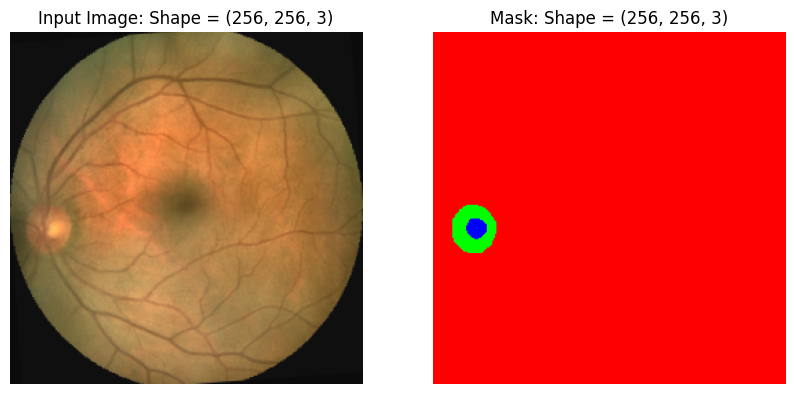

In [19]:
# ======================================
# Random Image and Mask Visualization
# ======================================

# ---------------------------
# Select Random Index
# ---------------------------
index = random.randint(0, imgData.shape[0] - 1)  # Ensure index is within bounds

# ---------------------------
# Create Subplots
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes = axes.flat  # Flatten the axes array for easier indexing

# ---------------------------
# Display Input Image
# ---------------------------
axes[0].imshow(
    imgData[index][:, :, ::-1]
)  # Convert BGR to RGB for proper visualization
axes[0].set_title(
    f"Input Image: Shape = {imgData[index].shape}"
)  # Set the title with image shape
axes[0].axis("off")  # Turn off axis labels for better visualization

# ---------------------------
# Display Corresponding Mask
# ---------------------------
axes[1].imshow(
    np.moveaxis(maskData[index].astype(np.float32), 0, -1), cmap="gray"
)  # Move channels to last axis
axes[1].set_title(
    f"Mask: Shape = {np.moveaxis(maskData[index], 0, -1).shape}"
)  # Set the title with mask shape
axes[1].axis("off")  # Turn off axis labels for better visualization


In [20]:
# ===========================
# Model Setup
# ===========================

# Initialize the UNet++ model with the specified parameters
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b7",  # Encoder backbone to extract features
    encoder_weights="imagenet",  # Pre-trained weights on ImageNet for the encoder
    in_channels=3,  # Number of input channels (e.g., RGB images have 3 channels)
    classes=num_classes,  # Number of output classes for segmentation
)


In [21]:
# ===========================
# Loss Functions
# ===========================

# Dice Loss: Measures overlap between predicted and ground truth masks
dice_loss_fn = smp.losses.DiceLoss(mode="multilabel")

# Jaccard Loss (IoU Loss): Measures intersection over union for segmentation tasks
iou_loss_fn = smp.losses.JaccardLoss(mode="multilabel")

# ===========================
# Optimizer
# ===========================

optimizer = torch.optim.Adam(model.parameters(), lr=modelParams.lr)
# optimizer = torch.optim.SGD(model.parameters(), lr=modelParams.lr, momentum=0.9)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=modelParams.lr, momentum=0.9)

# ===========================
# Learning Rate Scheduler
# ===========================

# ReduceLROnPlateau reduces the learning rate when validation loss plateaus
scheduler = ReduceLROnPlateau(
    optimizer,
    mode=modelParams.mode,
    factor=0.5,
    min_lr=(modelParams.lr / 100.0),
    patience=modelParams.patience,
)


# Check if GPU is available and set the device accordingly
# If GPU is available, the model will be moved to GPU for faster computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding

In [22]:
# ===========================
# Model Summary
# ===========================

# Display a detailed summary of the model architecture
summary(
    model,  # The PyTorch model to summarize
    input_size=(
        modelParams.BATCH_SIZE,  # Batch size for the input
        3,  # Number of input channels (e.g., RGB images have 3 channels)
        params.WIDTH,  # Input image width (specified in params)
        params.HEIGHT,  # Input image height (specified in params)
    ),  # Input size should match the model's expected input dimensions
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable",
    ],  # Columns to display in the summary
    col_width=20,  # Width of each column in the summary table
    row_settings=["var_names"],  # Display variable names in the summary
    device=device,  # Specify the device (CPU or GPU) where the model is located
)


Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
UnetPlusPlus (UnetPlusPlus)                                       [16, 3, 256, 256]    [16, 3, 256, 256]    --                   True
├─EfficientNetEncoder (encoder)                                   [16, 3, 256, 256]    [16, 3, 256, 256]    1,643,520            True
│    └─Conv2dStaticSamePadding (_conv_stem)                       [16, 3, 256, 256]    [16, 64, 128, 128]   1,728                True
│    │    └─ZeroPad2d (static_padding)                            [16, 3, 256, 256]    [16, 3, 257, 257]    --                   --
│    └─BatchNorm2d (_bn0)                                         [16, 64, 128, 128]   [16, 64, 128, 128]   128                  True
│    └─SiLU (_swish)                                              [16, 64, 128, 128]   [16, 64, 128, 128]   --                   --
│    └─ModuleList (_blocks)                                  

In [ ]:
# ============================
# Initialization
# ============================

# Initialize lists to store metrics for all epochs
epochs_list = []  # Stores the epoch numbers.
train_losses = []  # Stores the average training loss for each epoch.
val_losses = []  # Stores the average validation loss for each epoch.
iou_scores = []  # Stores the IoU (Intersection over Union) score for each epoch.
dice_scores = []  # Stores the Dice (F1) score for each epoch.
precisions = []  # Stores the precision for each epoch.
recalls = []  # Stores the recall (sensitivity) for each epoch.
specificities = []  # Stores the specificity (true negative rate) for each epoch.
accuracies = []  # Stores the accuracy for each epoch.
learning_rates = []  # Stores the learning rate used in each epoch.

# ============================
# Training Loop
# ============================

for epoch in range(modelParams.epochs):
    # ----------------------------
    # Training Phase
    # ----------------------------
    model.train()  # Set the model to training mode
    train_loss = 0  # Initialize training loss for the epoch

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)  # Move data to device
        optimizer.zero_grad()  # Reset gradients

        outputs = model(images)  # Forward pass
        if outputs.shape != masks.shape:  # Ensure shape consistency
            raise ValueError(
                f"Shape mismatch: outputs {outputs.shape}, masks {masks.shape} in training set"
            )

        loss = dice_loss_fn(outputs, masks) + iou_loss_fn(
            outputs, masks
        )  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters

        train_loss += loss.item()  # Accumulate training loss

    # ----------------------------
    # Validation Phase
    # ----------------------------
    model.eval()  # Set the model to evaluation mode
    val_loss = 0  # Initialize validation loss
    all_outputs = []  # Store predicted outputs
    all_masks = []  # Store ground truth masks

    with torch.no_grad():  # Disable gradient computation
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)  # Move data to device

            outputs = model(images)  # Forward pass
            if outputs.shape != masks.shape:  # Ensure shape consistency
                raise ValueError(
                    f"Shape mismatch: outputs {outputs.shape}, masks {masks.shape} in validation set"
                )

            loss = dice_loss_fn(outputs, masks) + iou_loss_fn(
                outputs, masks
            )  # Compute loss
            val_loss += loss.item()  # Accumulate validation loss

            all_outputs.append(outputs)  # Store outputs
            all_masks.append(masks)  # Store masks

    # ----------------------------
    # Metrics Calculation
    # ----------------------------
    all_outputs = torch.cat(all_outputs)  # Combine outputs
    all_masks = torch.cat(all_masks)  # Combine masks

    tp, fp, fn, tn = smp.metrics.get_stats(
        all_outputs, all_masks, mode="multilabel", threshold=0.5
    )
    iou_score = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
    dice_score = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
    precision = smp.metrics.precision(tp, fp, fn, tn, reduction="micro")
    recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro")
    specificity = smp.metrics.specificity(tp, fp, fn, tn, reduction="micro")
    accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="micro")

    train_loss /= len(train_loader)  # Average training loss
    val_loss /= len(val_loader)  # Average validation loss

    # ----------------------------
    # Learning Rate Adjustment
    # ----------------------------
    last_lr = optimizer.param_groups[0]["lr"]
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(val_loss)
    else:
        raise TypeError("Scheduler is not an instance of ReduceLROnPlateau.")

    # ----------------------------
    # Logging and Storing Metrics
    # ----------------------------
    print(
        f"Epoch {epoch + 1}/{modelParams.epochs} | "
        f"Training Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f} | "
        f"IoU Score: {iou_score:.4f} | Dice Score: {dice_score:.4f} | "
        f"Precision: {precision:.4f} | Recall: {recall:.4f} | "
        f"Specificity: {specificity:.4f} | Accuracy: {accuracy:.4f} | "
        f"Last Learning Rate: {last_lr}"
    )

    epochs_list.append(epoch + 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    iou_scores.append(iou_score.item())
    dice_scores.append(dice_score.item())
    precisions.append(precision.item())
    recalls.append(recall.item())
    specificities.append(specificity.item())
    accuracies.append(accuracy.item())
    learning_rates.append(last_lr)


In [ ]:
# ============================
# Save Training Metrics to CSV
# ============================

# ----------------------------
# Define File Name
# ----------------------------
fname = "Data/" + type(optimizer).__name__.capitalize() + f"_training_metrics_{modelParams.BACKBONE}_UNET_Plus_Plus.csv"
csv_file = fname

# ----------------------------
# Open CSV File for Writing
# ----------------------------
with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)

    # ----------------------------
    # Write Header Row
    # ----------------------------
    writer.writerow(
        [
            "Epoch",
            "Training Loss",
            "Validation Loss",
            "IoU Score",
            "Dice Score",
            "Precision",
            "Recall",
            "Specificity",
            "Accuracy",
            "Learning Rate",
        ]
    )

    # ----------------------------
    # Write Metrics for Each Epoch
    # ----------------------------
    for i in range(len(epochs_list)):
        writer.writerow(
            [
                epochs_list[i],
                train_losses[i],
                val_losses[i],
                iou_scores[i],
                dice_scores[i],
                precisions[i],
                recalls[i],
                specificities[i],
                accuracies[i],
                learning_rates[i],
            ]
        )


In [ ]:
# Visualize the saved parameters from the training metrics CSV file
visualize_saved_parameters(fname)


In [ ]:
# ===========================
# Evaluate on test set
# ===========================

# Set the model to evaluation mode to disable dropout and batch normalization
model.eval()

# ===========================
# Initialize storage lists
# ===========================
predicted_masks = []
ground_truth_masks = []
test_input_images = []

# ===========================
# Perform inference on test set
# ===========================
with torch.no_grad():
    for batch_images, batch_masks in test_loader:
        # Move data to the appropriate device
        batch_images, batch_masks = batch_images.to(device), batch_masks.to(device)

        # Forward pass through the model
        batch_outputs = model(batch_images)

        # Ensure outputs and masks have the same shape
        if batch_outputs.shape != batch_masks.shape:
            raise ValueError(
                f"Shape mismatch: outputs {batch_outputs.shape}, masks {batch_masks.shape} in test set"
            )

        # Append predictions, ground truth, and input images to respective lists
        predicted_masks.append(batch_outputs)
        ground_truth_masks.append(batch_masks)
        test_input_images.append(batch_images.cpu())

    # ===========================
    # Convert lists to tensors
    # ===========================
    predicted_masks = torch.cat(predicted_masks)
    ground_truth_masks = torch.cat(ground_truth_masks)
    test_input_images = torch.cat(test_input_images)

    # ===========================
    # Compute evaluation metrics
    # ===========================
    # Calculate True Positives, False Positives, False Negatives, True Negatives
    true_positives, false_positives, false_negatives, true_negatives = (
        smp.metrics.get_stats(
            predicted_masks, ground_truth_masks, mode="multilabel", threshold=0.5
        )
    )

    # Calculate Intersection over Union (IoU) score
    iou_score = smp.metrics.iou_score(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # Calculate Dice coefficient (F1 score)
    dice_score = smp.metrics.f1_score(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # Calculate Precision
    precision = smp.metrics.precision(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # Calculate Recall
    recall = smp.metrics.recall(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # Calculate Specificity (True Negative Rate)
    specificity = smp.metrics.specificity(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # Calculate Accuracy
    accuracy = smp.metrics.accuracy(
        true_positives,
        false_positives,
        false_negatives,
        true_negatives,
        reduction="micro",
    )

    # ===========================
    # Print evaluation results
    # ===========================
    print(
        f"Test Set Evaluation Metrics:\n\n"
        f" - Intersection over Union (IoU): {iou_score:.4f}\n"
        f" - Dice Coefficient (F1 Score): {dice_score:.4f}\n"
        f" - Precision: {precision:.4f}\n"
        f" - Recall: {recall:.4f}\n"
        f" - Specificity: {specificity:.4f}\n"
        f" - Accuracy: {accuracy:.4f}"
    )


In [ ]:
# ===========================
# Test Loop
# ===========================

# Ensure the test_loader is not empty
if len(test_loader) > 0:
    # ---------------------------
    # Random Batch Selection
    # ---------------------------
    idx = random.randint(0, len(test_loader) - 1)  # Randomly select a batch index

    # ---------------------------
    # Iterate Through Test Loader
    # ---------------------------
    for n, data in enumerate(test_loader):
        if n == idx:  # If the current batch index matches the selected index
            images, masks = data  # Extract images and masks from the batch

            # ---------------------------
            # Move Data to Device
            # ---------------------------
            images = images.to(
                device
            )  # Move images to the appropriate device (CPU/GPU)

            # ---------------------------
            # Model Prediction
            # ---------------------------
            outputs = model(images)  # Perform a forward pass through the model

            # ---------------------------
            # Post-Processing
            # ---------------------------
            pred_masks = torch.sigmoid(outputs)  # Convert logits to probabilities
            pred_masks_np = pred_masks.detach().cpu().numpy()  # Detach and move to CPU
            break  # Exit the loop after processing the selected batch
else:
    # ---------------------------
    # Error Handling
    # ---------------------------
    print(
        "Error: test_loader is empty. Ensure that the test dataset is properly loaded."
    )


In [ ]:
# ===============================
# Visualization of Predictions
# ===============================

for n in range(8):  # Loop to visualize 8 images in the selected batch
    # ---------------------------
    # Convert Image to NumPy Array
    # ---------------------------
    image_np = images[n].permute(1, 2, 0).cpu().numpy()  # Convert tensor to NumPy array
    image_np = image_np[:, :, ::-1]  # Convert from BGR to RGB for proper visualization

    # ---------------------------
    # Extract Ground Truth and Predicted Masks
    # ---------------------------
    gt_mask_np = masks[n].detach().cpu().squeeze().numpy()  # Ground truth mask
    pred_mask_np = pred_masks_np[n].squeeze()  # Predicted mask

    # ---------------------------
    # Adjust Mask Dimensions
    # ---------------------------
    gt_mask_np = np.moveaxis(gt_mask_np, 0, 2).astype(np.float32)  # Ground truth mask
    pred_mask_np = np.moveaxis(pred_mask_np, 0, 2).astype(np.float32)  # Predicted mask

    # ---------------------------
    # Binarize Predicted Mask
    # ---------------------------
    pred_mask_np = (pred_mask_np > 0.85).astype(np.float32)  # Thresholding

    # ---------------------------
    # Visualize Predictions
    # ---------------------------
    visualize_prediction(image_np, gt_mask_np, np.round(pred_mask_np))
